# BigCloneBench Prepared Data Summary

Summarize each prepared BCB split/type, including `non_clone`: code counts, pair counts, unique code ids referenced by pairs, and removal/filter counts recorded during preparation and graph pruning.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "spectral_code").exists() and (candidate / "pipelines").exists():
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from spectral_code.utils.dataset_paths import bcb_type_dir, output_root_for

BCB_ROOT = bcb_type_dir("non_clone").parent
print("Project root:", PROJECT_ROOT)
print("BCB prepared root:", BCB_ROOT)

Project root: c:\Users\koush\PyProjects\spectrals\Spectral-Software
BCB prepared root: C:\Users\koush\PyProjects\spectrals\data\bcb


In [2]:
def read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def count_lines(path: Path) -> int:
    if not path.exists():
        return 0
    with path.open("rb") as f:
        return sum(1 for _ in f)


def train_unique_code_ids(path: Path) -> int:
    ids = set()
    if not path.exists():
        return 0
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2:
                ids.add(parts[0])
                ids.add(parts[1])
    return len(ids)


def train_label_counts(path: Path) -> tuple[int, int]:
    positives = 0
    negatives = 0
    if not path.exists():
        return positives, negatives
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 3 and parts[2] == "1":
                positives += 1
            elif len(parts) >= 3 and parts[2] == "0":
                negatives += 1
    return positives, negatives


def split_name(data_dir: Path) -> str:
    rel = data_dir.relative_to(BCB_ROOT).as_posix()
    return rel.replace("/", "_")


BCB_VARIANTS = [
    {"split": "type1", "variant": "1", "label": "Type 1"},
    {"split": "type2", "variant": "2", "label": "Type 2"},
    {"split": "type3_all", "variant": "3/all", "label": "Type 3 All"},
    {"split": "type3_moderate", "variant": "3/moderate", "label": "Type 3 Moderate"},
    {"split": "type3_strong", "variant": "3/strong", "label": "Type 3 Strong"},
    {"split": "type3_very_strong", "variant": "3/very_strong", "label": "Type 3 Very Strong"},
    {"split": "type4", "variant": "4", "label": "Type 4"},
    {"split": "non_clone", "variant": "non_clone", "label": "Non Clone"},
]
VARIANT_BY_SPLIT = {item["split"]: item for item in BCB_VARIANTS}


def split_sort_key(name: str):
    order = {item["split"]: i for i, item in enumerate(BCB_VARIANTS, start=1)}
    return (order.get(name, 50), name)


expected_dirs = {bcb_type_dir(item["variant"]) for item in BCB_VARIANTS}
discovered_dirs = {path.parent for path in BCB_ROOT.rglob("metadata.json")} | {path.parent for path in BCB_ROOT.rglob("train.txt")}
candidate_dirs = sorted(expected_dirs | discovered_dirs, key=lambda p: split_sort_key(split_name(p)))
candidate_dirs

[WindowsPath('C:/Users/koush/PyProjects/spectrals/data/bcb/type1'),
 WindowsPath('C:/Users/koush/PyProjects/spectrals/data/bcb/type2'),
 WindowsPath('C:/Users/koush/PyProjects/spectrals/data/bcb/type3/all'),
 WindowsPath('C:/Users/koush/PyProjects/spectrals/data/bcb/type3/moderate'),
 WindowsPath('C:/Users/koush/PyProjects/spectrals/data/bcb/type3/strong'),
 WindowsPath('C:/Users/koush/PyProjects/spectrals/data/bcb/type3/very_strong'),
 WindowsPath('C:/Users/koush/PyProjects/spectrals/data/bcb/type4'),
 WindowsPath('C:/Users/koush/PyProjects/spectrals/data/bcb/non_clone')]

In [3]:
rows = []
variant_by_dir = {bcb_type_dir(item["variant"]): item for item in BCB_VARIANTS}
for data_dir in candidate_dirs:
    name = split_name(data_dir)
    variant_info = variant_by_dir.get(data_dir) or VARIANT_BY_SPLIT.get(name) or {"split": name, "variant": None, "label": name}
    variant = variant_info.get("variant")
    output_root = output_root_for("bcb", variant) if variant is not None else None
    graph_manifest = output_root / "clean_graphs" / "graph_shards_manifest.json" if output_root is not None else None
    spectral_manifest = output_root / "spectral_features" / "spectral_features_manifest.json" if output_root is not None else None
    graph_manifest_data = read_json(graph_manifest) if graph_manifest is not None else {}
    spectral_manifest_data = read_json(spectral_manifest) if spectral_manifest is not None else {}
    trained_json_files = sorted(output_root.glob("trained_*.json")) if output_root is not None and output_root.exists() else []
    pair_score_csv_files = sorted(output_root.glob("pair_scores_*.csv")) if output_root is not None and output_root.exists() else []
    metadata = read_json(data_dir / "metadata.json")
    graph_prune = read_json(data_dir / "graph_prune_metadata.json")
    train_path = data_dir / "train.txt"
    positive_pairs, non_clone_pairs = train_label_counts(train_path)

    graph_train_stats = (metadata.get("graph_pruned_pairs") or graph_prune.get("files", {}).get("train") or {})
    false_positive_before = metadata.get("false_positive_nonclone_pairs_before_code_filter")
    false_positive_after = metadata.get("false_positive_nonclone_pairs_after_code_filter")
    nonclone_removed_by_code_filters = None
    if false_positive_before is not None and false_positive_after is not None:
        nonclone_removed_by_code_filters = int(false_positive_before) - int(false_positive_after)

    full_positive_pairs = metadata.get("full_clone_type_positive_pairs")
    selected_positive_pairs = metadata.get("positive_clones")
    positive_pairs_not_selected_or_removed = None
    if full_positive_pairs is not None and selected_positive_pairs is not None:
        positive_pairs_not_selected_or_removed = int(full_positive_pairs) - int(selected_positive_pairs)

    rows.append({
        "split": name,
        "label": variant_info.get("label", name),
        "variant": variant,
        "data_dir": str(data_dir),
        "output_root": str(output_root) if output_root is not None else None,
        "code_rows_data_jsonl": count_lines(data_dir / "data.jsonl"),
        "pairs_train_txt": count_lines(train_path),
        "unique_code_ids_in_train": train_unique_code_ids(train_path),
        "positive_pairs_in_train": positive_pairs,
        "non_clone_pairs_in_train": non_clone_pairs,
        "detected_getter_setter_functions": metadata.get("detected_getter_setter_functions"),
        "excluded_getter_setter_functions": metadata.get("excluded_getter_setter_functions"),
        "excluded_unsupported_nested_java_method_functions": metadata.get("excluded_unsupported_nested_java_method_functions"),
        "strict_lecture_rejected": metadata.get("strict_lecture_rejected"),
        "false_positive_nonclone_pairs_available": metadata.get("false_positive_nonclone_pairs_available"),
        "false_positive_nonclone_pairs_after_code_filter": false_positive_after,
        "false_positive_removed_by_code_filters_total": nonclone_removed_by_code_filters,
        "false_positive_removed_by_getter_setter": metadata.get("false_positive_nonclone_pairs_removed_by_getter_setter"),
        "false_positive_removed_by_both_three_line": metadata.get("false_positive_nonclone_pairs_removed_by_both_three_line"),
        "false_positive_removed_by_other_code_filters": metadata.get("false_positive_nonclone_pairs_removed_by_other_code_filters"),
        "non_clone_pairs_before_code_id_budget": metadata.get("non_clone_pairs_before_code_id_budget"),
        "non_clone_pairs_after_code_id_budget": metadata.get("non_clone_pairs_after_code_id_budget"),
        "full_positive_pairs_in_dump_filter": full_positive_pairs,
        "selected_positive_pairs_after_filters": selected_positive_pairs,
        "positive_pairs_not_selected_or_removed": positive_pairs_not_selected_or_removed,
        "graph_prune_pairs_before": graph_train_stats.get("pairs_before"),
        "graph_prune_pairs_after": graph_train_stats.get("pairs_after"),
        "graph_prune_pairs_removed": graph_train_stats.get("pairs_removed_by_missing_graph"),
        "skipped_graph_function_ids": metadata.get("skipped_graph_function_ids") or graph_prune.get("skipped_graph_function_ids"),
        "train_positives_file_exists": (data_dir / "train_positives.txt").exists(),
        "type_labels_file_exists": (data_dir / "type_labels.tsv").exists(),
        "graph_manifest_exists": bool(graph_manifest and graph_manifest.exists()),
        "graph_manifest_methods": graph_manifest_data.get("total_methods"),
        "spectral_manifest_exists": bool(spectral_manifest and spectral_manifest.exists()),
        "spectral_manifest_methods": spectral_manifest_data.get("total_methods"),
        "trained_json_count": len(trained_json_files),
        "trained_json_files": ", ".join(path.name for path in trained_json_files),
        "pair_score_csv_count": len(pair_score_csv_files),
        "pipeline_timings_exists": bool(output_root and (output_root / "pipeline_timings.json").exists()),
    })


summary_df = pd.DataFrame(rows).sort_values("split")
display(summary_df)

compact_cols = [
    "split",
    "variant",
    "code_rows_data_jsonl",
    "pairs_train_txt",
    "unique_code_ids_in_train",
    "positive_pairs_in_train",
    "non_clone_pairs_in_train",
    "excluded_getter_setter_functions",
    "excluded_unsupported_nested_java_method_functions",
    "strict_lecture_rejected",
    "false_positive_removed_by_code_filters_total",
    "false_positive_removed_by_both_three_line",
    "graph_prune_pairs_removed",
    "train_positives_file_exists",
    "type_labels_file_exists",
    "graph_manifest_exists",
    "graph_manifest_methods",
    "spectral_manifest_exists",
    "spectral_manifest_methods",
    "trained_json_count",
]
display(summary_df[compact_cols])

,split,label,variant,data_dir,output_root,code_rows_data_jsonl,pairs_train_txt,unique_code_ids_in_train,positive_pairs_in_train,non_clone_pairs_in_train,...,train_positives_file_exists,type_labels_file_exists,graph_manifest_exists,graph_manifest_methods,spectral_manifest_exists,spectral_manifest_methods,trained_json_count,trained_json_files,pair_score_csv_count,pipeline_timings_exists
7,non_clone,Non Clone,non_clone,C:\Users\koush\PyProjects\spectrals\data\bcb\n...,C:\Users\koush\PyProjects\spectrals\outputs\bc...,55693,260708,55677,0,260708,...,False,False,True,55678,True,55678,0,,0,True
0,type1,Type 1,1,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,C:\Users\koush\PyProjects\spectrals\outputs\bc...,3603,45873,3603,45873,0,...,False,False,True,3603,True,3603,1,trained_bcb_type1_f1_pss_wasserstein.json,1,True
1,type2,Type 2,2,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,C:\Users\koush\PyProjects\spectrals\outputs\bc...,953,4106,954,4106,0,...,False,False,True,953,True,953,1,trained_bcb_type2_f1_pss_wasserstein.json,1,True
2,type3_all,Type 3 All,3/all,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,C:\Users\koush\PyProjects\spectrals\outputs\bc...,9039,105965,9039,105965,0,...,False,False,True,9039,True,9039,1,trained_bcb_type3_all_f1_pss_wasserstein.json,1,True
3,type3_moderate,Type 3 Moderate,3/moderate,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,C:\Users\koush\PyProjects\spectrals\outputs\bc...,7654,86041,7654,86041,0,...,False,False,True,7654,True,7654,1,trained_bcb_type3_moderate_f1_pss_wasserstein....,1,True
4,type3_strong,Type 3 Strong,3/strong,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,C:\Users\koush\PyProjects\spectrals\outputs\bc...,4640,16716,4640,16716,0,...,False,False,True,4640,True,4640,1,trained_bcb_type3_strong_f1_pss_wasserstein.json,1,True
5,type3_very_strong,Type 3 Very Strong,3/very_strong,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,C:\Users\koush\PyProjects\spectrals\outputs\bc...,1744,3208,1744,3208,0,...,False,False,True,1744,True,1744,1,trained_bcb_type3_very_strong_f1_pss_wasserste...,1,True
6,type4,Type 4,4,C:\Users\koush\PyProjects\spectrals\data\bcb\t...,C:\Users\koush\PyProjects\spectrals\outputs\bc...,14119,939436,14118,939436,0,...,False,False,True,14119,True,14119,1,trained_bcb_type4_f1_pss_wasserstein.json,1,True


,split,variant,code_rows_data_jsonl,pairs_train_txt,unique_code_ids_in_train,positive_pairs_in_train,non_clone_pairs_in_train,excluded_getter_setter_functions,excluded_unsupported_nested_java_method_functions,strict_lecture_rejected,false_positive_removed_by_code_filters_total,false_positive_removed_by_both_three_line,graph_prune_pairs_removed,train_positives_file_exists,type_labels_file_exists,graph_manifest_exists,graph_manifest_methods,spectral_manifest_exists,spectral_manifest_methods,trained_json_count
7,non_clone,non_clone,55693,260708,55677,0,260708,0.0,2600.0,0.0,18247.0,4677.0,77.0,False,False,True,55678,True,55678,0
0,type1,1,3603,45873,3603,45873,0,2.0,188.0,0.0,NaN,NaN,0.0,False,False,True,3603,True,3603,1
1,type2,2,953,4106,954,4106,0,0.0,4.0,122.0,NaN,NaN,0.0,False,False,True,953,True,953,1
2,type3_all,3/all,9039,105965,9039,105965,0,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,9039,True,9039,1
3,type3_moderate,3/moderate,7654,86041,7654,86041,0,4.0,108.0,0.0,NaN,NaN,0.0,False,False,True,7654,True,7654,1
4,type3_strong,3/strong,4640,16716,4640,16716,0,1.0,53.0,1.0,NaN,NaN,0.0,False,False,True,4640,True,4640,1
5,type3_very_strong,3/very_strong,1744,3208,1744,3208,0,0.0,161.0,7.0,NaN,NaN,0.0,False,False,True,1744,True,1744,1
6,type4,4,14119,939436,14118,939436,0,5.0,618.0,0.0,NaN,NaN,159.0,False,False,True,14119,True,14119,1


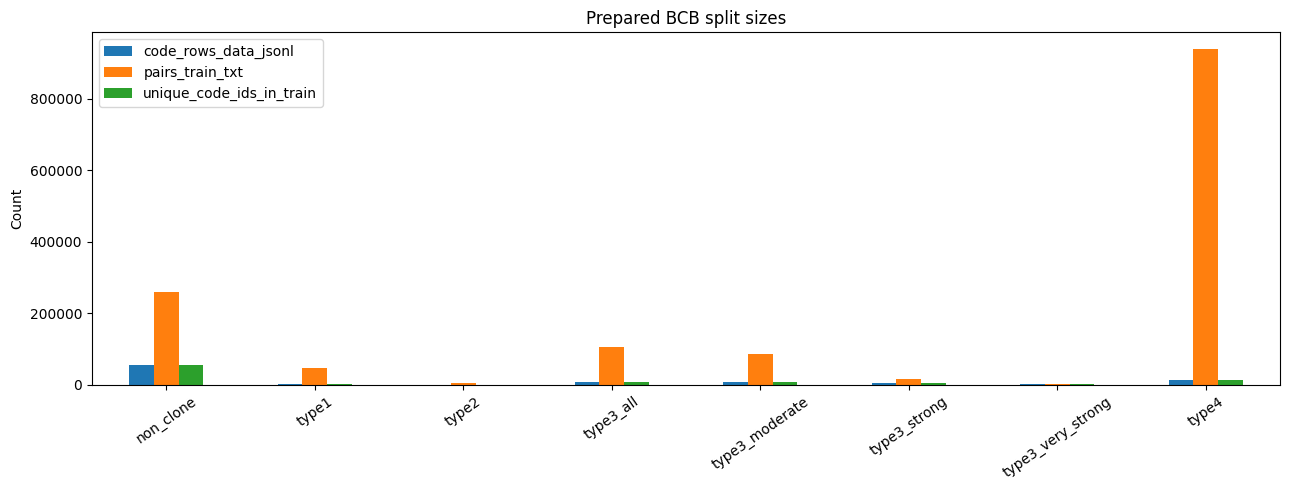

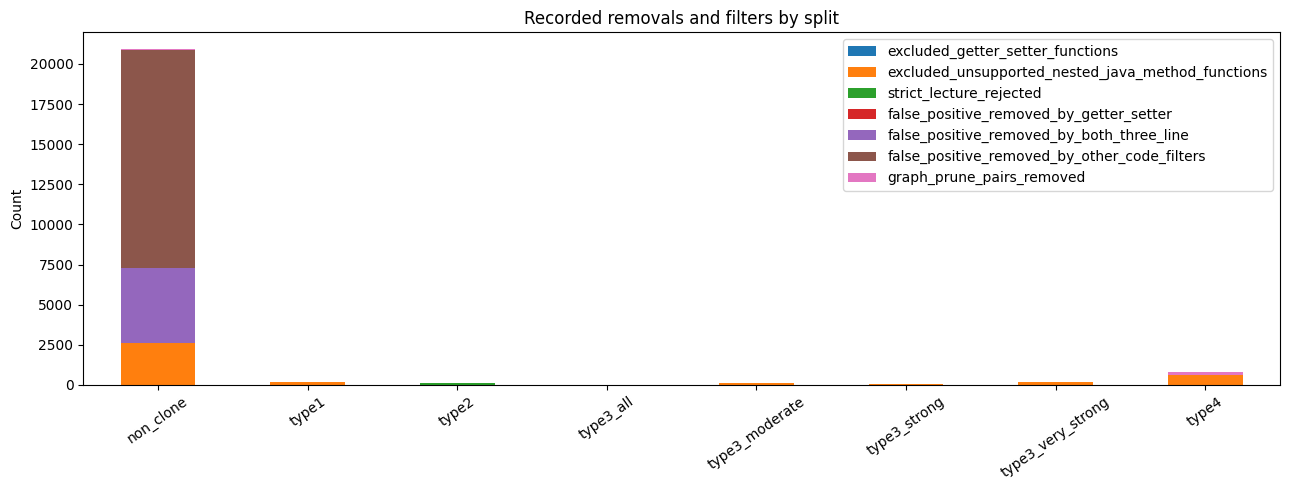

In [4]:
plot_df = summary_df.set_index("split")[["code_rows_data_jsonl", "pairs_train_txt", "unique_code_ids_in_train"]]
ax = plot_df.plot(kind="bar", figsize=(13, 5), rot=35)
ax.set_title("Prepared BCB split sizes")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

removal_cols = [
    "excluded_getter_setter_functions",
    "excluded_unsupported_nested_java_method_functions",
    "strict_lecture_rejected",
    "false_positive_removed_by_getter_setter",
    "false_positive_removed_by_both_three_line",
    "false_positive_removed_by_other_code_filters",
    "graph_prune_pairs_removed",
]
removal_df = summary_df.set_index("split")[removal_cols].fillna(0)
ax = removal_df.plot(kind="bar", stacked=True, figsize=(13, 5), rot=35)
ax.set_title("Recorded removals and filters by split")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.tight_layout()
plt.show()